In [97]:
# https://judge.nitro-ai.org/competitions/nitro/rise-2026-open-qualifier-2/1/view

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import random
import torch
from torch import nn
import torch.nn.functional as F

def seed_everything(seed=20260322):
 random.seed(seed)
 os.environ['PYTHONHASHSEED'] = str(seed)
 np.random.seed(seed)

 try:
     torch.manual_seed(seed)
     torch.cuda.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     torch.backends.cudnn.deterministic = True
     torch.backends.cudnn.benchmark = False
 except NameError:
     pass

seed_everything(20260322)

In [98]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/playful-sequences/train_data.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/playful-sequences/test_data.csv")
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/playful-sequences/sample_output.csv")

train.shape, test.shape, subm.shape

((100000, 17), (30000, 16), (30000, 3))

In [99]:
train.head()

,datapointID,subtaskID,Angular_Velocity_rad_s,Magnetic_Moment_Am2,Plate_Resonance_Hz,Precession_Angle_deg,Friction_Coefficient,Gravity_Vector_x,Gravity_Vector_y,Acoustic_Amplitude_dB,Tuning_Fork_Mass_g,Top_Inertia_Tensor_zz,Surface_Roughness_um,Release_Height_mm,Temperature_C,Magnetic_Field_Gradient_Tm,Target
0,query_000001,2,529.918095,NaN,9358.788710,6.254506,0.024204,0.000006,NaN,77.460356,47.670326,0.005070,3.786933,12.215896,34.686627,0.032404,1
1,query_000002,1,487.983777,4.915651,1258.815856,73.492362,0.056090,0.000006,NaN,104.739862,38.141021,0.008277,1.134007,62.917719,17.007986,0.265601,0
2,query_000003,1,345.098681,4.003950,8425.561454,31.033230,0.020378,0.000017,0.000009,63.398335,10.554692,0.003156,4.746432,14.622118,26.484398,0.921370,1
3,query_000004,2,970.950336,1.705413,7237.791779,78.983339,0.030368,-0.000011,-0.000004,117.176599,NaN,0.001690,4.887774,34.292051,34.735585,0.161256,0
4,query_000005,1,434.209023,5.004653,2956.426030,73.707073,0.026598,-0.000010,NaN,83.423059,13.455643,0.003174,0.785392,58.333491,33.389646,0.028310,0


In [100]:
deg_max = train['Precession_Angle_deg'].max()

train['Precession_Angle_deg_cyclic'] = np.sin(train['Precession_Angle_deg'] / deg_max * 2 * np.pi)
test['Precession_Angle_deg_cyclic'] = np.sin(test['Precession_Angle_deg'] / deg_max * 2 * np.pi)

In [101]:
train1 = train[train['subtaskID']==1].reset_index(drop=True)
train2 = train[train['subtaskID']==2].reset_index(drop=True)

test1 = test[test['subtaskID']==1].reset_index(drop=True)
test2 = test[test['subtaskID']==2].reset_index(drop=True)

len(train1), len(train2), len(test1), len(test2)

(50111, 49889, 14975, 15025)

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from catboost import Pool, CatBoostClassifier

def solve(train, test, features=None):
    if features is None:
        features = [c for c in train.columns if c not in ['subtaskID', 'datapointID', 'Target']]
    target_col = 'Target'

    X, y = train[features], train[target_col]
    X_test = test[features]

    fill = X.mean()
    X = X.fillna(fill)
    X_test = X_test.fillna(fill)
    
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, test_size=0.1, stratify=y)

    train_pool = Pool(X_train, y_train)
    valid_pool = Pool(X_valid, y_valid)

    params = {
        'iterations': 1000,
        'eval_metric': 'TotalF1:average=Macro',
        'metric_period': 200,
        'loss_function': 'Logloss',
        'max_depth': 3,
        'random_state': 42
    }
    
    model = CatBoostClassifier(**params)
    
    model.fit(train_pool, eval_set=valid_pool)

    y_pred_val = model.predict(X_valid)
    score = f1_score(y_valid, y_pred_val, average='macro')
    print(f'Score: {score:.5f}')
    
    return model, model.predict(X_test)

In [103]:
train.columns

Index(['datapointID', 'subtaskID', 'Angular_Velocity_rad_s',
       'Magnetic_Moment_Am2', 'Plate_Resonance_Hz', 'Precession_Angle_deg',
       'Friction_Coefficient', 'Gravity_Vector_x', 'Gravity_Vector_y',
       'Acoustic_Amplitude_dB', 'Tuning_Fork_Mass_g', 'Top_Inertia_Tensor_zz',
       'Surface_Roughness_um', 'Release_Height_mm', 'Temperature_C',
       'Magnetic_Field_Gradient_Tm', 'Target', 'Precession_Angle_deg_cyclic'],
      dtype='object')

In [104]:
model1, y_pred1 = solve(train1, test1, ['Angular_Velocity_rad_s', 'Magnetic_Moment_Am2', 'Plate_Resonance_Hz', 'Friction_Coefficient', 'Top_Inertia_Tensor_zz', 'Surface_Roughness_um', 'Magnetic_Field_Gradient_Tm'])
model2, y_pred2 = solve(train2, test2, ['Precession_Angle_deg', 'Friction_Coefficient', 'Acoustic_Amplitude_dB'])

Learning rate set to 0.081187
0:	learn: 0.7621456	test: 0.7637987	best: 0.7637987 (0)	total: 5.49ms	remaining: 5.48s
200:	learn: 0.8959594	test: 0.8898642	best: 0.8898642 (200)	total: 818ms	remaining: 3.25s
400:	learn: 0.9019036	test: 0.8942524	best: 0.8942524 (400)	total: 1.7s	remaining: 2.53s
600:	learn: 0.9032119	test: 0.8950513	best: 0.8950513 (600)	total: 2.61s	remaining: 1.73s
800:	learn: 0.9048303	test: 0.8950518	best: 0.8950518 (800)	total: 3.44s	remaining: 856ms
999:	learn: 0.9058722	test: 0.8940543	best: 0.8950518 (800)	total: 4.28s	remaining: 0us

bestTest = 0.8950518087
bestIteration = 800

Shrink model to first 801 iterations.
Score: 0.89505
Learning rate set to 0.081099
0:	learn: 0.6518648	test: 0.6630317	best: 0.6630317 (0)	total: 4.49ms	remaining: 4.49s
200:	learn: 0.7316646	test: 0.7412662	best: 0.7412662 (200)	total: 741ms	remaining: 2.94s
400:	learn: 0.7356343	test: 0.7461722	best: 0.7461722 (400)	total: 1.58s	remaining: 2.36s
600:	learn: 0.7373795	test: 0.7474702	be

In [105]:
np.bincount(y_pred1), np.bincount(y_pred2)

(array([7420, 7555]), array([11639,  3386]))

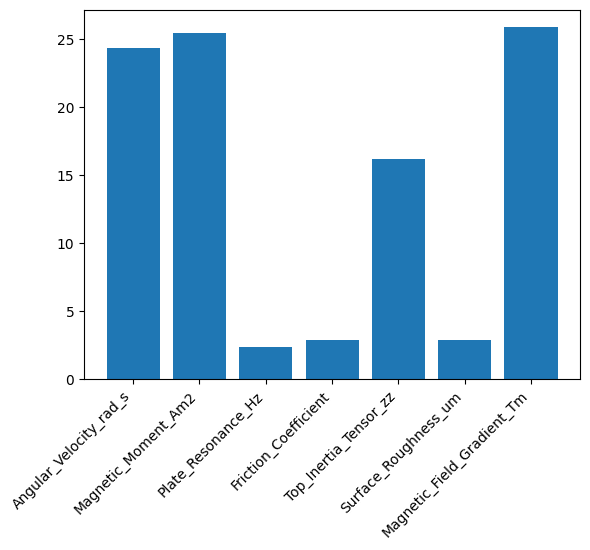

In [106]:
plt.bar(model1.feature_names_, model1.feature_importances_)
plt.xticks(rotation=45, ha='right')
plt.show()

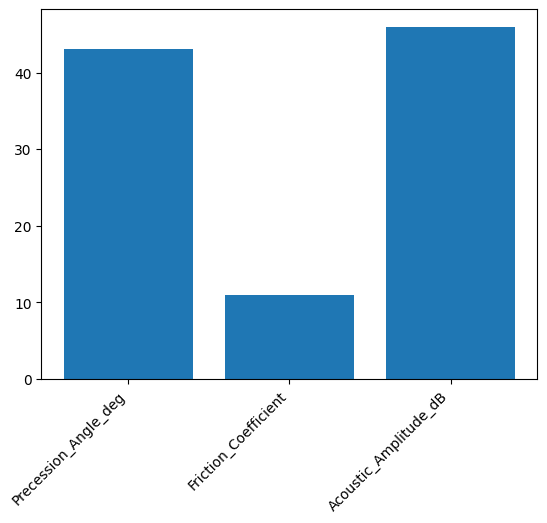

In [107]:
plt.bar(model2.feature_names_, model2.feature_importances_)
plt.xticks(rotation=45, ha='right')
plt.show()

In [108]:
subm = pd.DataFrame({
    'datapointID': test1['datapointID'].tolist() + test2['datapointID'].tolist(),
    'subtaskID': [1] * len(test1) + [2] * len(test2),
    'answer': y_pred1.tolist() + y_pred2.tolist()
})

subm.to_csv("submission.csv", index=False)

subm.head()

,datapointID,subtaskID,answer
0,query_100001,1,0
1,query_100002,1,0
2,query_100004,1,0
3,query_100006,1,1
4,query_100007,1,0
